In [1]:
import requests
import pandas as pd
import os
import matplotlib.pylab as plt
import seaborn as sns
from datetime import timedelta
from urllib.request import urlretrieve
import librosa
import librosa.display
from tqdm import tqdm
import soundfile as sf 
import numpy as np

# Download audios through the XenoCanto API and creation of the dataframe

In [2]:
def df_download(recordings):
    df = pd.DataFrame({
        'gen': [recording['gen'] for recording in recordings],
        'sp': [recording['sp'] for recording in recordings],
        'en': [recording['en'] for recording in recordings], 
        'file-name': [recording['file-name'] for recording in recordings], 
        'q': [recording['q'] for recording in recordings], 
        'length': [recording['length'] for recording in recordings]
        })

    df['Timedelta'] = pd.to_timedelta('00:' + df['length'])

    [urlretrieve(recording['file'],filename=os.path.join("audios/", (recording['file-name']))) for recording in recordings]

    df_especies.append(df)

    print("Finished")

    return df

In [3]:
df_especies=[]

In [7]:
# We search through audios of quality A and B and a maximum length of 30 seconds
# Use the key provided by creating an account at https://xeno-canto.org/
url = 'https://xeno-canto.org/api/3/recordings?query=sp:"tadarida teniotis"+q:A+len:"<30"+smp:">190000"&per_page=250&key='
response = requests.get(url)
print(response)
meta_data = response.json()
print(meta_data)
recordings = meta_data['recordings']

<Response [200]>
{'numRecordings': '750', 'numSpecies': '1', 'page': 1, 'numPages': 4, 'recordings': [{'id': '1062164', 'gen': 'Tadarida', 'sp': 'teniotis', 'ssp': '', 'grp': 'bats', 'en': 'European Free-tailed Bat', 'rec': 'Panagiotis Georgiakakis NHMC/Univ. of Crete', 'cnt': 'Greece', 'loc': 'Vavouledo village area', 'lat': '35.3864', 'lon': '23.7827', 'alt': '500', 'type': 'echolocation', 'sex': 'uncertain', 'stage': 'uncertain', 'method': 'field recording', 'url': '//xeno-canto.org/1062164', 'file': 'https://xeno-canto.org/1062164/download', 'file-name': 'XC1062164-Vavouledo-26Oct10-10-P.-han,-T.-ten_1_00024_999.wav', 'sono': {'small': '//xeno-canto.org/sounds/uploaded/OXILWAVDQT/ffts/XC1062164-small.png', 'med': '//xeno-canto.org/sounds/uploaded/OXILWAVDQT/ffts/XC1062164-med.png', 'large': '//xeno-canto.org/sounds/uploaded/OXILWAVDQT/ffts/XC1062164-large.png', 'full': '//xeno-canto.org/sounds/uploaded/OXILWAVDQT/ffts/XC1062164-full.png'}, 'osci': {'small': '//xeno-canto.org/sounds

In [8]:
European_Bat = df_download(recordings)

Finished


In [9]:
url = 'https://xeno-canto.org/api/3/recordings?query=sp:"rhinolophus hipposideros"+q:">C"+len:"<30"+smp:">190000"&per_page=250&key='
response = requests.get(url)
print(response)
meta_data = response.json()
print(meta_data)
recordings = meta_data['recordings']

<Response [200]>
{'numRecordings': '163', 'numSpecies': '1', 'page': 1, 'numPages': 1, 'recordings': [{'id': '1062124', 'gen': 'Rhinolophus', 'sp': 'hipposideros', 'ssp': '', 'grp': 'bats', 'en': 'Lesser Horseshoe Bat', 'rec': 'Panagiotis Georgiakakis NHMC/Univ. of Crete', 'cnt': 'Greece', 'loc': 'Sasalo village area', 'lat': '35.4009', 'lon': '23.708', 'alt': '350', 'type': 'echolocation', 'sex': 'uncertain', 'stage': 'uncertain', 'method': 'field recording', 'url': '//xeno-canto.org/1062124', 'file': 'https://xeno-canto.org/1062124/download', 'file-name': 'XC1062124-Sasalo-stream-01Oct10-29_0_00000_000.wav', 'sono': {'small': '//xeno-canto.org/sounds/uploaded/OXILWAVDQT/ffts/XC1062124-small.png', 'med': '//xeno-canto.org/sounds/uploaded/OXILWAVDQT/ffts/XC1062124-med.png', 'large': '//xeno-canto.org/sounds/uploaded/OXILWAVDQT/ffts/XC1062124-large.png', 'full': '//xeno-canto.org/sounds/uploaded/OXILWAVDQT/ffts/XC1062124-full.png'}, 'osci': {'small': '//xeno-canto.org/sounds/uploaded/OX

In [10]:
Lesser_Horseshoe_Bat = df_download(recordings)

Finished


Greater_Horseshoe_Bat = df_download(recordings)

In [11]:
url = 'https://xeno-canto.org/api/3/recordings?query=sp:"pipistrellus pygmaeus"+q:">C"+len:"<30"+smp:">190000"&per_page=250&key=c'
response = requests.get(url)
print(response)
meta_data = response.json()
print(meta_data)
recordings = meta_data['recordings']

<Response [200]>
{'numRecordings': '100', 'numSpecies': '1', 'page': 1, 'numPages': 1, 'recordings': [{'id': '1060750', 'gen': 'Pipistrellus', 'sp': 'pygmaeus', 'ssp': '', 'grp': 'bats', 'en': 'Soprano Pipistrelle', 'rec': 'Panagiotis Georgiakakis NHMC/Univ. of Crete', 'cnt': 'Greece', 'loc': 'Paparitsa, Liopesi', 'lat': '38.1657', 'lon': '21.9332', 'alt': '1300', 'type': 'echolocation', 'sex': 'uncertain', 'stage': 'uncertain', 'method': 'field recording', 'url': '//xeno-canto.org/1060750', 'file': 'https://xeno-canto.org/1060750/download', 'file-name': 'XC1060750-Pippyg-Paparitsa2021-sc-M00045.wav', 'sono': {'small': '//xeno-canto.org/sounds/uploaded/OXILWAVDQT/ffts/XC1060750-small.png', 'med': '//xeno-canto.org/sounds/uploaded/OXILWAVDQT/ffts/XC1060750-med.png', 'large': '//xeno-canto.org/sounds/uploaded/OXILWAVDQT/ffts/XC1060750-large.png', 'full': '//xeno-canto.org/sounds/uploaded/OXILWAVDQT/ffts/XC1060750-full.png'}, 'osci': {'small': '//xeno-canto.org/sounds/uploaded/OXILWAVDQT/

In [12]:
Soprano_Pipistrelle = df_download(recordings)

Finished


In [13]:
url = 'https://xeno-canto.org/api/3/recordings?query=sp:"pipistrellus pipistrellus"+q:"A"+len:"2-30"+smp:">190000"&per_page=250&key='
response = requests.get(url)
print(response)
meta_data = response.json()
print(meta_data)
recordings = meta_data['recordings']

<Response [200]>
{'numRecordings': '354', 'numSpecies': '1', 'page': 1, 'numPages': 2, 'recordings': [{'id': '1061363', 'gen': 'Pipistrellus', 'sp': 'pipistrellus', 'ssp': '', 'grp': 'bats', 'en': 'Common Pipistrelle', 'rec': 'Panagiotis Georgiakakis NHMC/Univ. of Crete', 'cnt': 'Greece', 'loc': 'Katara, Metsovo', 'lat': '39.8028', 'lon': '21.2278', 'alt': '1600', 'type': 'echolocation', 'sex': 'uncertain', 'stage': 'uncertain', 'method': 'field recording', 'url': '//xeno-canto.org/1061363', 'file': 'https://xeno-canto.org/1061363/download', 'file-name': 'XC1061363-Metsovo-2021-d1000_3-M00007_00000_000.wav', 'sono': {'small': '//xeno-canto.org/sounds/uploaded/OXILWAVDQT/ffts/XC1061363-small.png', 'med': '//xeno-canto.org/sounds/uploaded/OXILWAVDQT/ffts/XC1061363-med.png', 'large': '//xeno-canto.org/sounds/uploaded/OXILWAVDQT/ffts/XC1061363-large.png', 'full': '//xeno-canto.org/sounds/uploaded/OXILWAVDQT/ffts/XC1061363-full.png'}, 'osci': {'small': '//xeno-canto.org/sounds/uploaded/OXIL

In [14]:
Common_Pipistrelle = df_download(recordings)

Finished


In [15]:
url = 'https://xeno-canto.org/api/3/recordings?query=sp:"pipistrellus kuhlii"+q:"A"+len:"<30"+smp:">190000"&per_page=250&key='
response = requests.get(url)
print(response)
meta_data = response.json()
print(meta_data)
recordings = meta_data['recordings']

<Response [200]>
{'numRecordings': '421', 'numSpecies': '1', 'page': 1, 'numPages': 2, 'recordings': [{'id': '1062209', 'gen': 'Pipistrellus', 'sp': 'kuhlii', 'ssp': '', 'grp': 'bats', 'en': "Kuhl's Pipistrelle", 'rec': 'Panagiotis Georgiakakis NHMC/Univ. of Crete', 'cnt': 'Greece', 'loc': 'Pardi forest, Vistagi', 'lat': '35.19', 'lon': '24.76', 'alt': '1000', 'type': 'echolocation', 'sex': 'uncertain', 'stage': 'uncertain', 'method': 'field recording', 'url': '//xeno-canto.org/1062209', 'file': 'https://xeno-canto.org/1062209/download', 'file-name': 'XC1062209-Pardi-5Nov09-01-P.han,-H.savii;,-T.-ten_0_00019_999.wav', 'sono': {'small': '//xeno-canto.org/sounds/uploaded/OXILWAVDQT/ffts/XC1062209-small.png', 'med': '//xeno-canto.org/sounds/uploaded/OXILWAVDQT/ffts/XC1062209-med.png', 'large': '//xeno-canto.org/sounds/uploaded/OXILWAVDQT/ffts/XC1062209-large.png', 'full': '//xeno-canto.org/sounds/uploaded/OXILWAVDQT/ffts/XC1062209-full.png'}, 'osci': {'small': '//xeno-canto.org/sounds/upl

In [16]:
Kuhl_Pipistrelle = df_download(recordings)

Finished


In [17]:
url = 'https://xeno-canto.org/api/3/recordings?query=sp:"nyctalus leisleri"+q:">C"+len:"<30"+smp:">190000"&per_page=250&key='
response = requests.get(url)
print(response)
meta_data = response.json()
print(meta_data)
recordings = meta_data['recordings']

<Response [200]>
{'numRecordings': '73', 'numSpecies': '1', 'page': 1, 'numPages': 1, 'recordings': [{'id': '1060582', 'gen': 'Nyctalus', 'sp': 'leisleri', 'ssp': '', 'grp': 'bats', 'en': "Leisler's Noctule", 'rec': 'Panagiotis Georgiakakis NHMC/Univ. of Crete', 'cnt': 'Greece', 'loc': 'Lithochori to Raptopoulo', 'lat': '39.133', 'lon': '21.494', 'alt': '910', 'type': 'echolocation', 'sex': 'uncertain', 'stage': 'uncertain', 'method': 'field recording', 'url': '//xeno-canto.org/1060582', 'file': 'https://xeno-canto.org/1060582/download', 'file-name': 'XC1060582-Nyclei-AgApostol_20250710_044010.wav', 'sono': {'small': '//xeno-canto.org/sounds/uploaded/OXILWAVDQT/ffts/XC1060582-small.png', 'med': '//xeno-canto.org/sounds/uploaded/OXILWAVDQT/ffts/XC1060582-med.png', 'large': '//xeno-canto.org/sounds/uploaded/OXILWAVDQT/ffts/XC1060582-large.png', 'full': '//xeno-canto.org/sounds/uploaded/OXILWAVDQT/ffts/XC1060582-full.png'}, 'osci': {'small': '//xeno-canto.org/sounds/uploaded/OXILWAVDQT/wa

In [18]:
Leisler_Noctule = df_download(recordings)

Finished


Greater_Noctule = df_download(recordings)

Greater_Myotis = df_download(recordings)

In [19]:
url = 'https://xeno-canto.org/api/3/recordings?query=sp:"myotis daubentonii"+q:">C"+len:"<30"+smp:">190000"&per_page=250&key='
response = requests.get(url)
print(response)
meta_data = response.json()
print(meta_data)
recordings = meta_data['recordings']

<Response [200]>
{'numRecordings': '53', 'numSpecies': '1', 'page': 1, 'numPages': 1, 'recordings': [{'id': '1018942', 'gen': 'Myotis', 'sp': 'daubentonii', 'ssp': '', 'grp': 'bats', 'en': "Daubenton's Myotis", 'rec': 'Peter Nilsson', 'cnt': 'Sweden', 'loc': 'Tavnäs, Bräcke Municipality, Jämtlands län', 'lat': '62.9777', 'lon': '15.1995', 'alt': '320', 'type': 'echolocation', 'sex': '', 'stage': '', 'method': 'field recording', 'url': '//xeno-canto.org/1018942', 'file': 'https://xeno-canto.org/1018942/download', 'file-name': 'XC1018942-S4U12344_20250721_003613.wav', 'sono': {'small': '//xeno-canto.org/sounds/uploaded/WNIKCXGARA/ffts/XC1018942-small.png', 'med': '//xeno-canto.org/sounds/uploaded/WNIKCXGARA/ffts/XC1018942-med.png', 'large': '//xeno-canto.org/sounds/uploaded/WNIKCXGARA/ffts/XC1018942-large.png', 'full': '//xeno-canto.org/sounds/uploaded/WNIKCXGARA/ffts/XC1018942-full.png'}, 'osci': {'small': '//xeno-canto.org/sounds/uploaded/WNIKCXGARA/wave/XC1018942-small.png', 'med': '/

In [20]:
Daubenton_Myotis = df_download(recordings)

Finished


In [22]:
url = 'https://xeno-canto.org/api/3/recordings?query=sp:"miniopterus schreibersii"+q:">C"+len:"<30"+smp:">190000"&per_page=250&key='
response = requests.get(url)
print(response)
meta_data = response.json()
print(meta_data)
recordings = meta_data['recordings']

<Response [200]>
{'numRecordings': '182', 'numSpecies': '1', 'page': 1, 'numPages': 1, 'recordings': [{'id': '1062116', 'gen': 'Miniopterus', 'sp': 'schreibersii', 'ssp': '', 'grp': 'bats', 'en': "Schreibers's Long-fingered Bat", 'rec': 'Panagiotis Georgiakakis NHMC/Univ. of Crete', 'cnt': 'Greece', 'loc': 'Vougioukliana', 'lat': '35.4049', 'lon': '23.784', 'alt': '480', 'type': 'echolocation', 'sex': 'uncertain', 'stage': 'uncertain', 'method': 'field recording', 'url': '//xeno-canto.org/1062116', 'file': 'https://xeno-canto.org/1062116/download', 'file-name': 'XC1062116-Roumata-1-05Oct09-33-Phan_PYGMAEUS_1_00015_000.wav', 'sono': {'small': '//xeno-canto.org/sounds/uploaded/OXILWAVDQT/ffts/XC1062116-small.png', 'med': '//xeno-canto.org/sounds/uploaded/OXILWAVDQT/ffts/XC1062116-med.png', 'large': '//xeno-canto.org/sounds/uploaded/OXILWAVDQT/ffts/XC1062116-large.png', 'full': '//xeno-canto.org/sounds/uploaded/OXILWAVDQT/ffts/XC1062116-full.png'}, 'osci': {'small': '//xeno-canto.org/soun

In [23]:
Schreibers_Bat = df_download(recordings)

Finished


In [24]:
url = 'https://xeno-canto.org/api/3/recordings?query=sp:"eptesicus serotinus"+q:">C"+len:"<30"+smp:">190000"&per_page=250&key='
response = requests.get(url)
print(response)
meta_data = response.json()
print(meta_data)
recordings = meta_data['recordings']

<Response [200]>
{'numRecordings': '141', 'numSpecies': '1', 'page': 1, 'numPages': 1, 'recordings': [{'id': '1054249', 'gen': 'Eptesicus', 'sp': 'serotinus', 'ssp': '', 'grp': 'bats', 'en': 'Eurasian Serotine', 'rec': 'Sandra Rademaker', 'cnt': 'Netherlands', 'loc': 'Bilthoven, De Bilt, Utrecht', 'lat': '52.1335', 'lon': '5.2184', 'alt': '10', 'type': 'echolocation, social call', 'sex': 'uncertain', 'stage': 'uncertain', 'method': 'field recording', 'url': '//xeno-canto.org/1054249', 'file': 'https://xeno-canto.org/1054249/download', 'file-name': 'XC1054249-EPTSER_20250710_222209.wav', 'sono': {'small': '//xeno-canto.org/sounds/uploaded/EEKHMUVUIY/ffts/XC1054249-small.png', 'med': '//xeno-canto.org/sounds/uploaded/EEKHMUVUIY/ffts/XC1054249-med.png', 'large': '//xeno-canto.org/sounds/uploaded/EEKHMUVUIY/ffts/XC1054249-large.png', 'full': '//xeno-canto.org/sounds/uploaded/EEKHMUVUIY/ffts/XC1054249-full.png'}, 'osci': {'small': '//xeno-canto.org/sounds/uploaded/EEKHMUVUIY/wave/XC1054249-

In [25]:
Eurasian_Serotine = df_download(recordings)

Finished


In [26]:
url = 'https://xeno-canto.org/api/3/recordings?query=sp:"hypsugo savii"+q:"A"+len:"<30"+smp:">190000"&per_page=250&key='
response = requests.get(url)
print(response)
meta_data = response.json()
print(meta_data)
recordings = meta_data['recordings']

<Response [200]>
{'numRecordings': '548', 'numSpecies': '1', 'page': 1, 'numPages': 3, 'recordings': [{'id': '1061990', 'gen': 'Hypsugo', 'sp': 'savii', 'ssp': '', 'grp': 'bats', 'en': "Savi's Pipistrelle", 'rec': 'Panagiotis Georgiakakis NHMC/Univ. of Crete', 'cnt': 'Greece', 'loc': 'Mountain forest, Leptokarya', 'lat': '41.0497', 'lon': '25.8553', 'alt': '750', 'type': 'echolocation', 'sex': 'uncertain', 'stage': 'uncertain', 'method': 'field recording', 'url': '//xeno-canto.org/1061990', 'file': 'https://xeno-canto.org/1061990/download', 'file-name': 'XC1061990-Orfeas-D500-28to29June2020-M16109.wav', 'sono': {'small': '//xeno-canto.org/sounds/uploaded/OXILWAVDQT/ffts/XC1061990-small.png', 'med': '//xeno-canto.org/sounds/uploaded/OXILWAVDQT/ffts/XC1061990-med.png', 'large': '//xeno-canto.org/sounds/uploaded/OXILWAVDQT/ffts/XC1061990-large.png', 'full': '//xeno-canto.org/sounds/uploaded/OXILWAVDQT/ffts/XC1061990-full.png'}, 'osci': {'small': '//xeno-canto.org/sounds/uploaded/OXILWAVDQ

In [27]:
Savi_Pipistrelle = df_download(recordings)

Finished


In [28]:
url = 'https://xeno-canto.org/api/3/recordings?query=sp:"barbastella barbastellus"+q:">C"+len:"<30"+smp:">190000"&per_page=250&key='
response = requests.get(url)
print(response)
meta_data = response.json()
print(meta_data)
recordings = meta_data['recordings']

<Response [200]>
{'numRecordings': '72', 'numSpecies': '1', 'page': 1, 'numPages': 1, 'recordings': [{'id': '1062739', 'gen': 'Barbastella', 'sp': 'barbastellus', 'ssp': '', 'grp': 'bats', 'en': 'Western Barbastelle', 'rec': 'Sara Poppelaars Greensway', 'cnt': 'Sweden', 'loc': 'Lindesberg Municipality, Örebro County', 'lat': '59.5893', 'lon': '15.1096', 'alt': '220', 'type': 'echolocation', 'sex': '', 'stage': '', 'method': 'field recording', 'url': '//xeno-canto.org/1062739', 'file': 'https://xeno-canto.org/1062739/download', 'file-name': 'XC1062739-2024-08-28_232639.wav', 'sono': {'small': '//xeno-canto.org/sounds/uploaded/ESYDFBJFNY/ffts/XC1062739-small.png', 'med': '//xeno-canto.org/sounds/uploaded/ESYDFBJFNY/ffts/XC1062739-med.png', 'large': '//xeno-canto.org/sounds/uploaded/ESYDFBJFNY/ffts/XC1062739-large.png', 'full': '//xeno-canto.org/sounds/uploaded/ESYDFBJFNY/ffts/XC1062739-full.png'}, 'osci': {'small': '//xeno-canto.org/sounds/uploaded/ESYDFBJFNY/wave/XC1062739-small.png', '

In [29]:
Western_Barbastelle = df_download(recordings)

Finished


# EDA

In [30]:
# Species names
dataframes_especies = {
    'European Free-tailed Bat': European_Bat, 
    'Lesser Horseshoe Bat': Lesser_Horseshoe_Bat,
    'Soprano Pipistrelle': Soprano_Pipistrelle,
    'Common Pipistrelle': Common_Pipistrelle,
    'Kuhls Pipistrelle': Kuhl_Pipistrelle, 
    'Leislers Noctule': Leisler_Noctule, 
    'Daubentons Myotis': Daubenton_Myotis,
    'Schreibers Long-fingered Bat': Schreibers_Bat,
    'Eurasian Serotine': Eurasian_Serotine,
    'Savis Pipistrelle': Savi_Pipistrelle, 
    'Western Barbastelle': Western_Barbastelle,
}

# Time of audio by species
totales_timedelta = {}

for especie, df in dataframes_especies.items():
    total_duracion = df['Timedelta'].sum()
    totales_timedelta[especie] = total_duracion

df_comparacion = pd.DataFrame(
    list(totales_timedelta.items()), 
    columns=['Especie', 'Duracion_Total_Timedelta']
)

In [31]:
df_comparacion

,Especie,Duracion_Total_Timedelta
0,European Free-tailed Bat,0 days 00:16:10
1,Lesser Horseshoe Bat,0 days 00:10:31
2,Soprano Pipistrelle,0 days 00:16:49
3,Common Pipistrelle,0 days 00:48:38
4,Kuhls Pipistrelle,0 days 00:18:22
5,Leislers Noctule,0 days 00:09:24
6,Daubentons Myotis,0 days 00:07:46
7,Schreibers Long-fingered Bat,0 days 00:13:12
8,Eurasian Serotine,0 days 00:33:57
9,Savis Pipistrelle,0 days 00:13:48


In [32]:
df_comparacion['Duracion_Segundos'] = df_comparacion['Duracion_Total_Timedelta'].dt.total_seconds()

/var/folders/qz/0qttfh8j69jctp5r096r0jw40000gn/T/ipykernel_20660/859276526.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


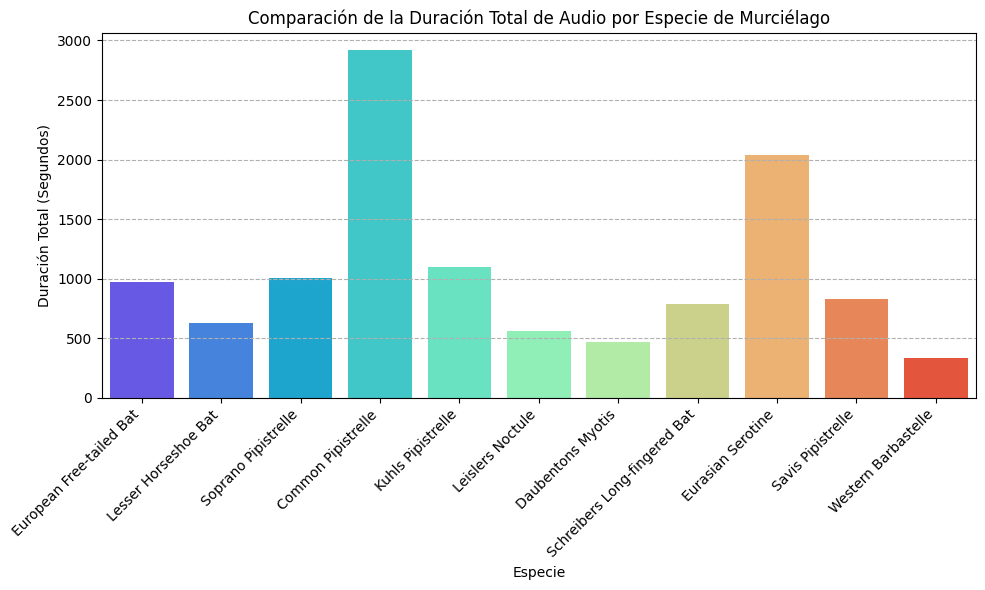

In [33]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x='Especie', 
    y='Duracion_Segundos', 
    data=df_comparacion,
    palette='rainbow' 
)

plt.title('Comparación de la Duración Total de Audio por Especie de Murciélago')
plt.xlabel('Especie')
plt.ylabel('Duración Total (Segundos)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--')
plt.tight_layout()
plt.show()

In [34]:
df_bats = pd.concat(df_especies, axis=0)
df_bats

,gen,sp,en,file-name,q,length,Timedelta
0,Tadarida,teniotis,European Free-tailed Bat,"XC1062164-Vavouledo-26Oct10-10-P.-han,-T.-ten_...",A,0:04,0 days 00:00:04
1,Tadarida,teniotis,European Free-tailed Bat,"XC1062157-Vavouledo-26Oct10-07-H.s_P.k,-P.-han...",A,0:04,0 days 00:00:04
2,Tadarida,teniotis,European Free-tailed Bat,XC1062125-Sasalo-stream-01Oct10-29_0_00005_000...,A,0:04,0 days 00:00:04
3,Tadarida,teniotis,European Free-tailed Bat,XC1061936-Orfeas-D500-14to15Oct2020-M01935.wav,A,0:00,0 days 00:00:00
4,Tadarida,teniotis,European Free-tailed Bat,XC1061935-Orfeas-D500-14to15Oct2020-M01501.wav,A,0:00,0 days 00:00:00
...,...,...,...,...,...,...,...
67,Barbastella,barbastellus,Western Barbastelle,XC822052-mops2216normalpassB.wav,B,0:03,0 days 00:00:03
68,Barbastella,barbastellus,Western Barbastelle,XC822042-mops2212normal.wav,B,0:02,0 days 00:00:02
69,Barbastella,barbastellus,Western Barbastelle,XC822041-mops2213coll.wav,B,0:01,0 days 00:00:01
70,Barbastella,barbastellus,Western Barbastelle,XC805682-9_Car251310-2021-Pass1-C1-011693-SINI...,B,0:02,0 days 00:00:02


In [35]:
df_bats.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1784 entries, 0 to 71
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype          
---  ------     --------------  -----          
 0   gen        1784 non-null   object         
 1   sp         1784 non-null   object         
 2   en         1784 non-null   object         
 3   file-name  1784 non-null   object         
 4   q          1784 non-null   object         
 5   length     1784 non-null   object         
 6   Timedelta  1784 non-null   timedelta64[ns]
dtypes: object(6), timedelta64[ns](1)
memory usage: 111.5+ KB


In [36]:
df_bats['en'].unique()

array(['European Free-tailed Bat', 'Lesser Horseshoe Bat',
       'Soprano Pipistrelle', 'Common Pipistrelle', "Kuhl's Pipistrelle",
       "Leisler's Noctule", "Daubenton's Myotis",
       "Schreibers's Long-fingered Bat", 'Eurasian Serotine',
       "Savi's Pipistrelle", 'Western Barbastelle'], dtype=object)

/var/folders/qz/0qttfh8j69jctp5r096r0jw40000gn/T/ipykernel_20660/130761300.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(df_bats,x='en',palette='rainbow')


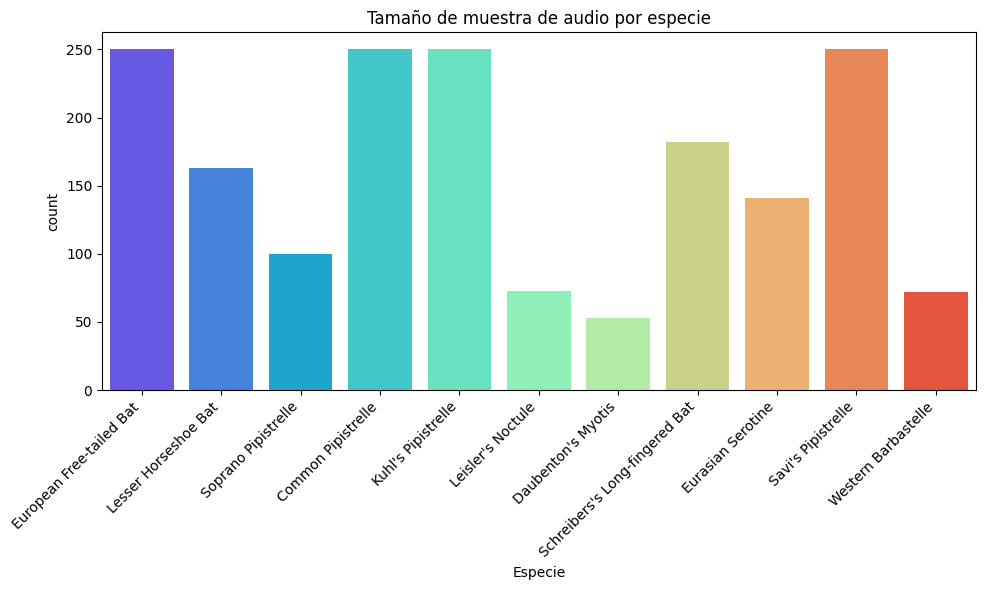

In [37]:
plt.figure(figsize=(10,6))
sns.countplot(df_bats,x='en',palette='rainbow')

plt.title('Tamaño de muestra de audio por especie')
plt.xlabel('Especie')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [159]:
#Check there aren't any audios under 192000Hz

archivos = glob.glob("audios/*.wav", recursive=True)

for f in archivos:
    info = sf.info(f)
    if info.samplerate < 192000:
        print(f"{f}-> {info.samplerate}Hz")

# Spectogram creation

In [2]:
os.makedirs("spectograms",exist_ok=True) #crear una carpeta nueva para meter los archivos png
#df_model = df_bats[['en','file-name']] 
#df_model.to_csv('en_wav.cvs', index=False) #esta va a ser nuestro cvs para leer cada archivo wav
#df_bats.to_csv('metadata.cvs',index=False)
meta = pd.read_csv('metadata.cvs')

In [4]:
audios= ('audios/'+meta['file-name'])

y, sr = librosa.load(audios[1330])
y

array([-1.01403784e-04, -4.56720940e-04, -4.49520448e-05, ...,
        8.26551986e-04,  9.92305810e-04,  1.63481291e-03],
      shape=(661489,), dtype=float32)

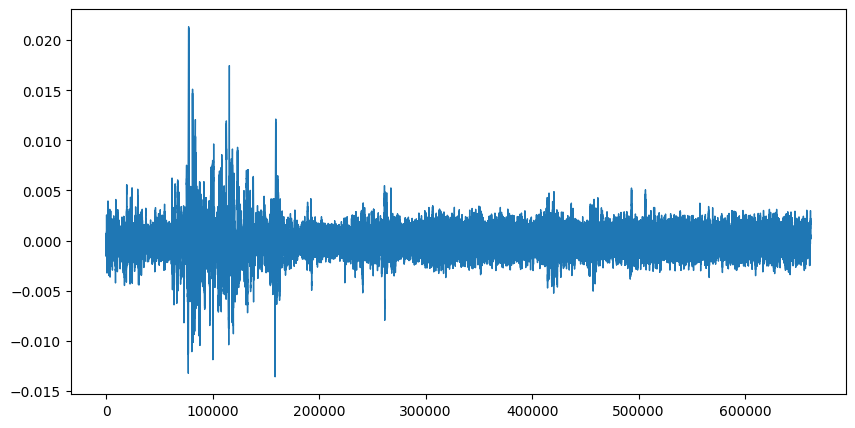

In [56]:
target_len = 192000
if len(y) < target_len:
    y = np.pad(y, (0, target_len - len(y)), mode='constant') #We use padding on shorter audios on constant to avoid creating false patterns
pd.Series(y).plot(figsize=(10,5), lw=1)
plt.show()

In [66]:
D= librosa.stft(y)
S_db = librosa.power_to_db(np.abs(D), ref=np.max)

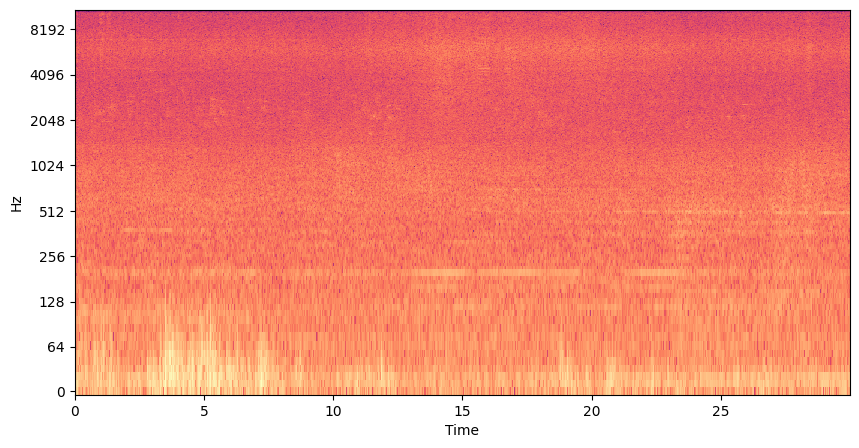

In [67]:
fig, ax= plt.subplots(figsize=(10,5))
img = librosa.display.specshow(S_db,
                              x_axis='time',
                              y_axis='log',
                              ax=ax)

In [133]:
df

,en,file-name
0,European Free-tailed Bat,"XC1062164-Vavouledo-26Oct10-10-P.-han,-T.-ten_..."
1,European Free-tailed Bat,"XC1062157-Vavouledo-26Oct10-07-H.s_P.k,-P.-han..."
2,European Free-tailed Bat,XC1062125-Sasalo-stream-01Oct10-29_0_00005_000...
3,European Free-tailed Bat,XC1061936-Orfeas-D500-14to15Oct2020-M01935.wav
4,European Free-tailed Bat,XC1061935-Orfeas-D500-14to15Oct2020-M01501.wav
...,...,...
1779,Western Barbastelle,XC822052-mops2216normalpassB.wav
1780,Western Barbastelle,XC822042-mops2212normal.wav
1781,Western Barbastelle,XC822041-mops2213coll.wav
1782,Western Barbastelle,XC805682-9_Car251310-2021-Pass1-C1-011693-SINI...


In [205]:
CSV_PATH   = 'en_wav.cvs'       
OUT_DIR    = "spectograms"
DURATION   = 1.0  
TARGET_SR  = 192000
N_MELS     = 128
N_FFT      = 4096
HOP_LENGTH = 1024 #(time resolution ≈ 1024/192000 ≈ 5.3 ms)
FMIN       = 15000

df = pd.read_csv(CSV_PATH)

df['species'] = df['en'].astype(str).str.replace(" ", "_")  
df['filename'] = df['file-name']                    

for _, row in tqdm(df.iterrows(), total=len(df)):
    species = row['species']
    filename = row['filename']

    wav_path = os.path.join('audios', filename)
    png_name = os.path.splitext(filename)[0] + ".png" #coge el nombre original del archivo .wav y le agrega .png
    out_png = os.path.join(OUT_DIR, png_name)

    try:
        y, sr = librosa.load(wav_path, sr=192000, mono=True)

        target_len = 192000
        if len(y) < target_len:
            y = np.pad(y, (0, target_len - len(y)), mode='constant') #hacemos padding con ceros para no crear patrones falsos

        # Mel spectrogram
        S = librosa.feature.melspectrogram(
            y=y,
            sr=sr,
            n_fft=N_FFT,
            hop_length=HOP_LENGTH,
            n_mels=N_MELS,
            fmin=FMIN,
            fmax=sr//2, # Nyquist theorem: you must sample an analog signal at more than double its highest frequency (bandwidth) to perfectly reconstruct it digitally, preventing distortion called aliasing, where high frequencies masquerade as lower ones
            power=2.0
        )
        S_db = librosa.power_to_db(S, ref=np.max)

        fig = plt.figure(figsize=(3, 3), dpi=150)
        librosa.display.specshow(S_db, sr=sr, hop_length=HOP_LENGTH,
                                 x_axis=None, y_axis=None, fmax=sr//2)
        
        plt.subplots_adjust(left=0, right=1, top=1, bottom=0)
        plt.axis('off')
        
        plt.savefig(out_png, bbox_inches='tight', pad_inches=0, dpi=150)
        plt.close(fig)

    except Exception as e:
        print(f"Error processing {filename}: {e}")

100%|██████████| 1784/1784 [03:09<00:00,  9.40it/s]


# Graphs 

In [53]:
meta.loc[1700]

gen                                                    Hypsugo
sp                                                       savii
en                                          Savi's Pipistrelle
file-name    XC1057870-Hsavii-SOUDA-04_20210609_052543_000.wav
q                                                            A
length                                                    0:04
Timedelta                                      0 days 00:00:04
Name: 1700, dtype: object

Audio length: 5.00 seconds
Sample rate: 192000 Hz


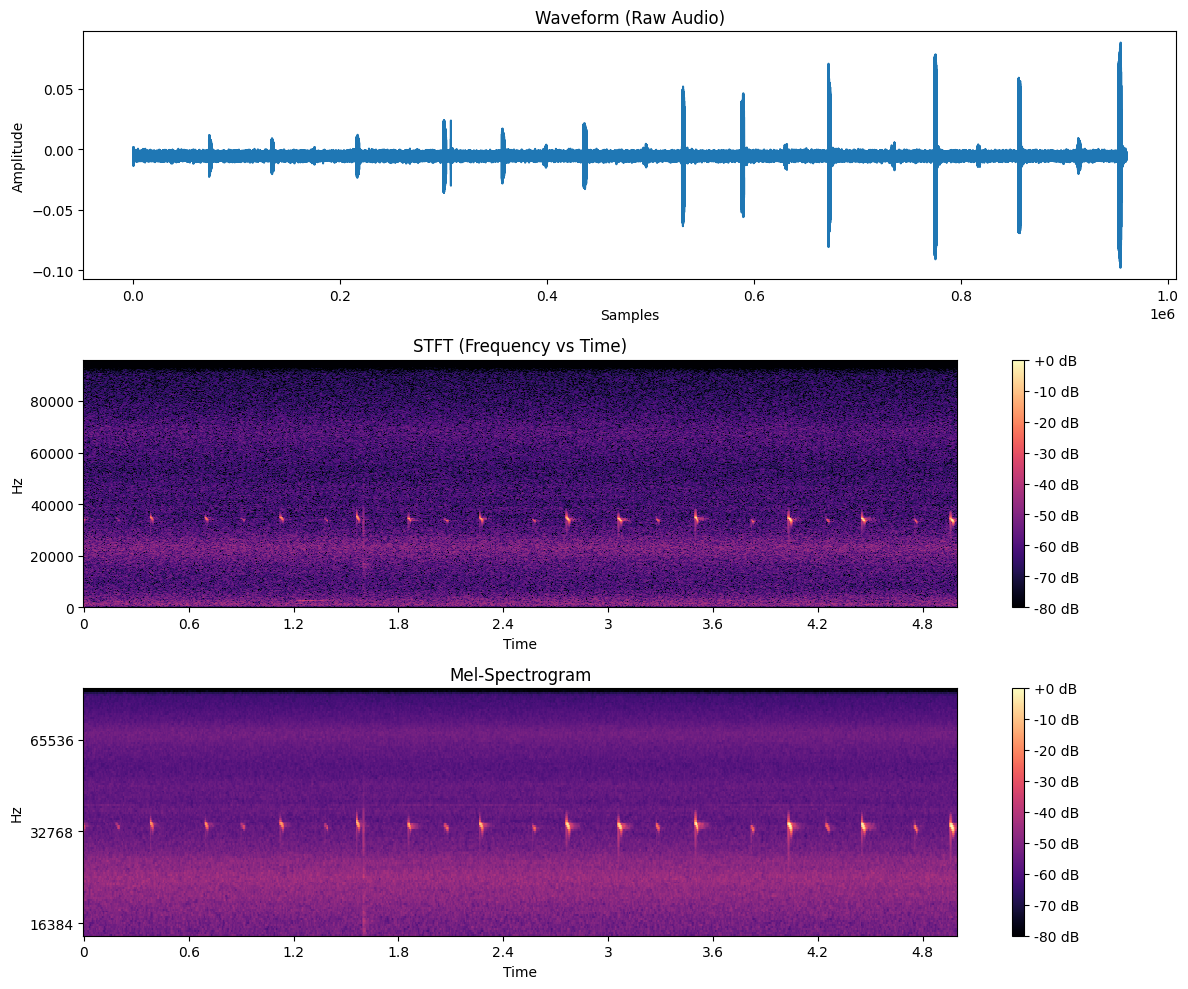

In [52]:
import librosa
import librosa.display
import numpy as np
import matplotlib.pyplot as plt

# ---------- Parámetros ----------
TARGET_SR = 192000
N_FFT = 4096
HOP_LENGTH = 1024
N_MELS = 128
FMIN = 15000
# --------------------------------

# 1️⃣ Cargar audio
y, sr = librosa.load(audios[1700], sr=TARGET_SR, mono=True)

print(f"Audio length: {len(y)/sr:.2f} seconds")
print(f"Sample rate: {sr} Hz")

# 2️⃣ STFT
stft = librosa.stft(y, n_fft=N_FFT, hop_length=HOP_LENGTH)
stft_db = librosa.amplitude_to_db(np.abs(stft), ref=np.max)

# 3️⃣ Mel-spectrogram
fmax = min(sr / 2, 100000)

mel_spec = librosa.feature.melspectrogram(
    y=y,
    sr=sr,
    n_fft=N_FFT,
    hop_length=HOP_LENGTH,
    n_mels=N_MELS,
    fmin=FMIN,
    fmax=fmax,
    power=2.0
)

mel_db = librosa.power_to_db(mel_spec, ref=np.max)

# 4️⃣ Visualización
fig, ax = plt.subplots(3, 1, figsize=(12, 10))

# ---- Audio waveform ----
ax[0].plot(y)
ax[0].set_title("Waveform (Raw Audio)")
ax[0].set_xlabel("Samples")
ax[0].set_ylabel("Amplitude")

# ---- STFT ----
librosa.display.specshow(
    stft_db,
    sr=sr,
    hop_length=HOP_LENGTH,
    x_axis="time",
    y_axis="hz",
    ax=ax[1]
)
ax[1].set_title("STFT (Frequency vs Time)")
fig.colorbar(ax[1].collections[0], ax=ax[1], format="%+2.0f dB")

# ---- Mel-spectrogram ----
librosa.display.specshow(
    mel_db,
    sr=sr,
    hop_length=HOP_LENGTH,
    x_axis="time",
    y_axis="mel",
    fmin=FMIN,
    fmax=fmax,
    ax=ax[2]
)
ax[2].set_title("Mel-Spectrogram")
fig.colorbar(ax[2].collections[0], ax=ax[2], format="%+2.0f dB")

plt.tight_layout()
plt.show()


/var/folders/qz/0qttfh8j69jctp5r096r0jw40000gn/T/ipykernel_82967/25044309.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(meta,x='en',palette='viridis')


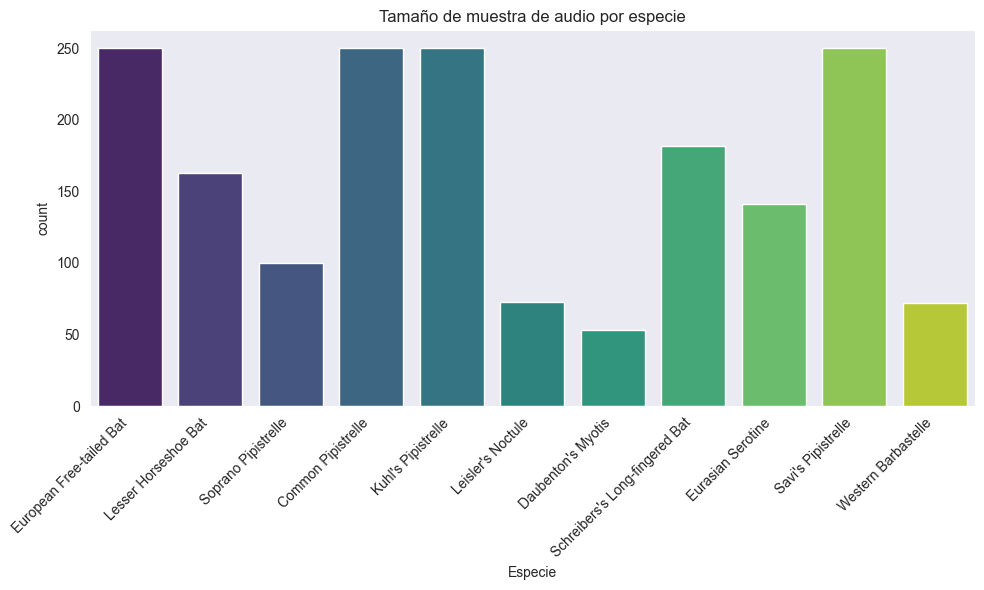

In [13]:
plt.figure(figsize=(10,6))
sns.countplot(meta,x='en',palette='viridis')
sns.set_style(style='dark')
plt.title('Tamaño de muestra de audio por especie')
plt.xlabel('Especie')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()